<a href="https://colab.research.google.com/github/jane-disciullo/sp500-backtesting-strategy/blob/main/03_strategy_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Strategy Comparison Overview

Comparing three investment strategies using historical SPY data rom 2015-2025:

- **Buy & Hold:** Invests in SPY and remains invested throughout the period.
- **50-Day Moving Average:** Holds SPY when the closing price is above its 50-day moving average and moves to cash otherwise.
- **200-Day Moving Average:** Holds SPY when the closing price is above its 200-day moving average and moves to cash otherwise.

The goal is to determine whether moving-average strategies provide a meaningful improvement in risk-adjusted performance compared with a simple buy-and-hold approach.

This notebook was developed with assistance from AI tools for debugging, troubleshooting, and syntax correction.

In [61]:
import sys
import pandas as pd
sys.path.insert(0, "/content/sp500-backtesting-strategy")

In [62]:
from src.data import load_spy_data
from src.signals import generate_ma_signal
from src.backtest import run_backtest
from src.metrics import calculate_total_return

In [63]:
price = load_spy_data(
    start="2015-01-01",
    end="2026-01-01",
    interval="1d"
)

print(f"Data loaded: {price.shape[0]} rows")
print(f"Date range: {price.index.min()} to {price.index.max()}")

/content/sp500-backtesting-strategy/src/data.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(
[*********************100%***********************]  1 of 1 completed

Data loaded: 2766 rows
Date range: 2015-01-02 00:00:00 to 2025-12-31 00:00:00


In [64]:
buy_hold = price.copy()
ma_50 = price.copy()
ma_200 = price.copy()

In [65]:
ma_50 = generate_ma_signal(ma_50, ma=50)
ma_200 = generate_ma_signal(ma_200, ma=200)

In [66]:
ma_50 = run_backtest(ma_50, starting_balance=100000)
ma_200 = run_backtest(ma_200, starting_balance=100000)

In [67]:
ma_50_metrics = calculate_total_return(ma_50)
ma_200_metrics = calculate_total_return(ma_200)

print("50-day MA:")
print(ma_50_metrics)

print("\n200-day MA:")
print(ma_200_metrics)

50-day MA:
{'final_bench': np.float64(399743.0009112753), 'final_strategy': np.float64(213151.87037165463), 'bench_total_return': np.float64(2.997430009112753), 'sys_total_return': np.float64(1.1315187037165462)}

200-day MA:
{'final_bench': np.float64(399743.0009112753), 'final_strategy': np.float64(288678.28873451654), 'bench_total_return': np.float64(2.997430009112753), 'sys_total_return': np.float64(1.8867828873451655)}


In [68]:
import numpy as np

years = (price.index[-1] - price.index[0]).days / 365.25

comparison = pd.DataFrame({
    "Strategy": ["Buy & Hold", "50-Day MA", "200-Day MA"],
    "Final Balance": [
        ma_200_metrics["final_bench"],
        ma_50_metrics["final_strategy"],
        ma_200_metrics["final_strategy"]
    ],
    "Total Return": [
        ma_200_metrics["bench_total_return"],
        ma_50_metrics["sys_total_return"],
        ma_200_metrics["sys_total_return"]
    ]
})

comparison["CAGR"] = (
    (comparison["Final Balance"] / 100000) ** (1 / years) - 1
)

comparison

,Strategy,Final Balance,Total Return,CAGR
0,Buy & Hold,399743.000911,2.997430,0.134309
1,50-Day MA,213151.870372,1.131519,0.071257
2,200-Day MA,288678.288735,1.886783,0.101220


In [69]:
print(ma_50.columns.tolist())

['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Return', 'Bench_Bal', 'MA', 'Long', 'Sys_Ret', 'Sys_Bal']


In [70]:
import numpy as np

def calculate_risk_metrics(data, balance_column):
    # Calculate actual daily portfolio returns from portfolio balance
    returns = data[balance_column].pct_change().dropna()

    # Annualized Sharpe ratio
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

    # Maximum drawdown
    balance = data[balance_column].dropna()
    drawdown = balance / balance.cummax() - 1
    max_drawdown = drawdown.min()

    return sharpe, max_drawdown

In [71]:
# Buy & Hold
bh_sharpe, bh_max_dd = calculate_risk_metrics(
    ma_200,
    "Bench_Bal"
)

# 50-day MA
ma50_sharpe, ma50_max_dd = calculate_risk_metrics(
    ma_50,
    "Sys_Bal"
)

# 200-day MA
ma200_sharpe, ma200_max_dd = calculate_risk_metrics(
    ma_200,
    "Sys_Bal"
)

print(f"Buy & Hold Sharpe: {bh_sharpe:.2f}")
print(f"Buy & Hold Max Drawdown: {bh_max_dd:.2%}")

print(f"\n50-Day MA Sharpe: {ma50_sharpe:.2f}")
print(f"50-Day MA Max Drawdown: {ma50_max_dd:.2%}")

print(f"\n200-Day MA Sharpe: {ma200_sharpe:.2f}")
print(f"200-Day MA Max Drawdown: {ma200_max_dd:.2%}")

Buy & Hold Sharpe: 0.81
Buy & Hold Max Drawdown: -33.72%

50-Day MA Sharpe: 0.71
50-Day MA Max Drawdown: -20.26%

200-Day MA Sharpe: 0.90
200-Day MA Max Drawdown: -19.81%


In [73]:
comparison_display = comparison.copy()

comparison_display["Final Balance"] = (
    comparison_display["Final Balance"].map("${:,.2f}".format)
)

comparison_display["Total Return"] = (
    comparison["Total Return"] * 100
).round(2).astype(str) + "%"

comparison_display["CAGR"] = (
    comparison["CAGR"] * 100
).round(2).astype(str) + "%"

comparison_display["Sharpe Ratio"] = (
    comparison["Sharpe Ratio"].round(2)
)

comparison_display["Max Drawdown"] = (
    comparison["Max Drawdown"] * 100
).round(2).astype(str) + "%"

comparison_display

,Strategy,Final Balance,Total Return,CAGR,Sharpe Ratio,Max Drawdown
0,Buy & Hold,"$399,743.00",299.74%,13.43%,0.81,-33.72%
1,50-Day MA,"$213,151.87",113.15%,7.13%,0.71,-20.26%
2,200-Day MA,"$288,678.29",188.68%,10.12%,0.90,-19.81%


In [74]:
import matplotlib.pyplot as plt

## Portfolio Growth Analysis

The chart below compares the growth of a hypothetical $100,000 investment under each strategy over the 2015–2025 period.

Portfolio growth provides a visual comparison of both performance and drawdown behavior. While buy-and-hold produces the highest ending portfolio value, the moving-average strategies may reduce exposure during periods of market weakness. Comparing the growth paths alongside the performance metrics helps evaluate the tradeoff between maximizing returns and managing downside risk.

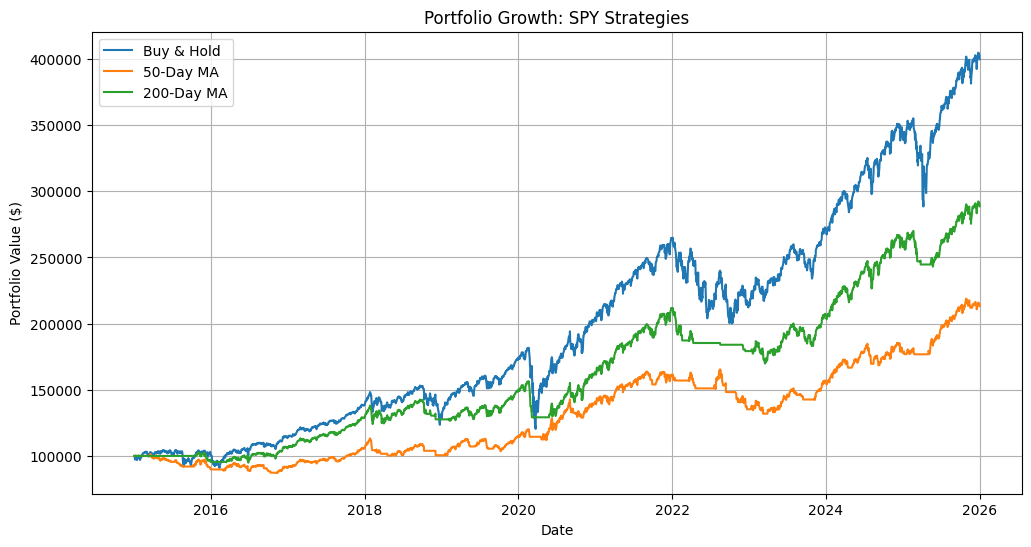

In [75]:
plt.figure(figsize=(12, 6))

plt.plot(
    ma_200.index,
    ma_200["Bench_Bal"],
    label="Buy & Hold"
)

plt.plot(
    ma_50.index,
    ma_50["Sys_Bal"],
    label="50-Day MA"
)

plt.plot(
    ma_200.index,
    ma_200["Sys_Bal"],
    label="200-Day MA"
)

plt.title("Portfolio Growth: SPY Strategies")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)

plt.show()